# Google Page Rank

In [28]:
import numpy as np
import matplotlib.pyplot as plt

### 4.95

$$
    \boldsymbol{H}=\begin{pmatrix}
        0&0&1/3&0&0&0\\
        1/2&0&1/3&0&0&0\\
        1/2&1&0&0&0&0\\
        0&0&0&0&1/2&1\\
        0&0&1/3&1/2&0&0\\
        0&0&0&1/2&1/2&0
    \end{pmatrix}
$$

### 4.96

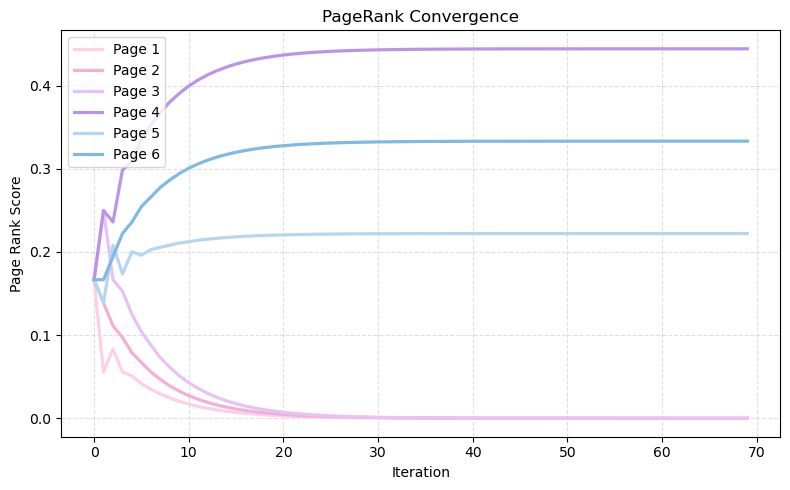

In [29]:
H = np.array([
    [0,   0,   1/3, 0,   0,   0],
    [1/2, 0,   1/3, 0,   0,   0],
    [1/2, 1,   0,   0,   0,   0],
    [0,   0,   0,   0,   1/2, 1],
    [0,   0,   1/3, 1/2, 0,   0],
    [0,   0,   0,   1/2, 1/2, 0],
])

cute_colors=["#fbd1ea", "#f3afd6", "#e8c2f7", "#bc94e7", "#b6d6ef", "#80b9e1"]

# initialize page ranks to all be equal
n = H.shape[0]
x = np.ones(n) / n

# for plotting rank evolution
hist = [x.copy()]
tol = 1e-6

# iter
while True:
    x_new = H @ x
    hist.append(x_new.copy())

    # stop when converged
    if np.linalg.norm(x_new - x, ord=1) < tol:
        break

    x = x_new

hist = np.array(hist)

plt.figure(figsize=(8,5))
for i in range(n):
    plt.plot(hist[:,i], label=f'Page {i+1}', color=cute_colors[i], linewidth=2.3)
plt.xlabel('Iteration')
plt.ylabel('Page Rank Score')
plt.title('PageRank Convergence')
plt.grid(alpha=0.4, linestyle='--')
plt.tight_layout()
plt.legend()
plt.savefig('convergence1.png')
plt.show()


In [30]:
# final pageranks
print('Final PageRanks:')
for i, val in enumerate(x_new):
    print(f'\tPage {i+1}: {val:.6f}')

Final PageRanks:
	Page 1: 0.000000
	Page 2: 0.000001
	Page 3: 0.000001
	Page 4: 0.444443
	Page 5: 0.222222
	Page 6: 0.333332


Plotted iterative convergence of PageRank scores for web graph in Figure 4.3. Pages 4-6 dominate the steady-state distribution while pages 1-3 decay to zero due to lack of incoming links.

The final steady-state PageRank vector is:
$$
\boldsymbol{x}_\text{converged}=\begin{pmatrix}
0\\
0\\
0\\
4/9\\
2/9\\
1/3
\end{pmatrix}
$$

### 4.97
For an $n\times n$ hyperlink matrix $\boldsymbol{H}$ to be stochastic, each column must be a probability vector, meaning all entries are non-negative and sum up to 1. This is only true if every page in the web has at least one out-link. If a page has no outgoing links, the corresponding column in $\boldsymbol{H}$ will contain all zeroes and break the stochastic property. In terms of the underlying Markov process, this would prevent convergence to a unique steady-state solution.

### 4.98
If $\boldsymbol{A}$ is an $n\times n$ stochastic matrix and $\boldsymbol{x}_0$ is some initial vector for the difference equation $\boldsymbol{x}_{n+1}=\boldsymbol{A}\boldsymbol{x}_n$, then the steady-state vector is 
$$
x_\text{equilibrium}=\lim_{k\to\infty}\boldsymbol{A}^k\boldsymbol{x}_0=\lim_{k\to\infty}c_n\lambda_n^k\boldsymbol{v}_n=c_1\boldsymbol{v}_1
$$
where $\boldsymbol{v}_1$ is the eigenvector corresponding to eigenvalue $\lambda=1$. Since all eigenvalues $\lambda_i$ with $|\lambda_i|<1$ vanish as $k\to\infty$, we are left with the $\lambda=1$ term. For a stochastic matrix, this dominant eigenvector represents the steady-state distribution of the system, aka the long-term PageRank vector.

### 4.99
Instead of repeatedly computing $\boldsymbol{x}_{n+1}=\boldsymbol{A}\boldsymbol{x}_n$, Theorem 4.9 tells us that we can skip the iteration entirely and just find the dominant eigenvector of the matrix $\boldsymbol{H}$ (the one associated with eigenvalue $\lambda=1$). This leads to the same steady-state PageRank vector.

### 4.100
Use new method to find the resulting PageRank vector and rank the pages in order of importance.

In [31]:
# get eigvals/eigvecs
eigvals, eigvecs = np.linalg.eig(H)

# get largest val (lambda=1)
idx = np.argmin(np.abs(eigvals-1))
v = np.real(eigvecs[:,idx])

# normalize eigvec to sum to 1
v /= np.sum(v)

# final PageRank vec
print('Final PageRanks:')
for i, val in enumerate(v):
    print(f'\tPage {i+1}: {val:.3f}')


Final PageRanks:
	Page 1: 0.000
	Page 2: 0.000
	Page 3: 0.000
	Page 4: 0.444
	Page 5: 0.222
	Page 6: 0.333


This gives us the same result as the iterative method in **4.96**.

### 4.101
Write the $\boldsymbol{H}$ matrix and find the initial state $\boldsymbol{x}_0$.

$$\boldsymbol{H}=\begin{pmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 1/3 & 0 \\
1/3 & 0 & 1/3 & 0 & 0 & 0 & 0 & 0 \\
1/3 & 1 & 0 & 0 & 1/4 & 0 & 1/3 & 0 \\
0 & 0 & 0 & 0 & 1/4 & 1 & 0 & 1 \\
0 & 0 & 1/3 & 1/3 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1/3 & 1/4 & 0 & 0 & 0 \\
1/3 & 0 & 1/3 & 0 & 1/4 & 0 & 0 & 0 \\
0 & 0 & 0 & 1/3 & 0 & 0 & 1/3 & 0 \\
\end{pmatrix}
$$

$$
\boldsymbol{x}_0=\begin{pmatrix}1/8\\1/8\\1/8\\1/8\\1/8\\1/8\\1/8\\1/8\end{pmatrix}
$$

Find steady state PageRank vector using the two methods described:
one using the iterative difference equation and the other using The-
orem 4.9 and the dominant eigenvector.

In [32]:
H = np.array([
    [0, 0, 0, 0, 0, 0, 1/3, 0],
    [1/3, 0, 1/3, 0, 0, 0, 0, 0],
    [1/3, 1, 0, 0, 1/4, 0, 1/3, 0],
    [0, 0, 0, 0, 1/4, 1, 0, 1],
    [0, 0, 1/3, 1/3, 0, 0, 0, 0],
    [0, 0, 0, 1/3, 1/4, 0, 0, 0],
    [1/3, 0, 1/3, 0, 1/4, 0, 0, 0],
    [0, 0, 0, 1/3, 0, 0, 1/3, 0]
])

cute_colors=["#ffeba2", "#fcc2c6", "#f1c0e8", "#cfbaf0", "#a3c4f3", "#90dbf4", "#8eecf5", "#98f5e1"]

#### Difference Equation Method

In [33]:
# initialize page ranks to all be equal
n = H.shape[0]
x = np.ones(n) / n

# for plotting rank evolution
hist = [x.copy()]
tol = 1e-6

# iter
while True:
    x_new = H @ x
    hist.append(x_new.copy())

    # stop when converged
    if np.linalg.norm(x_new - x, ord=1) < tol:
        break

    x = x_new

hist = np.array(hist)

cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0, 1, n))
# cute_colors=["#ffe278", "#fca0a6", "#e8addd", "#c3a8ee", "#7d99e6", "#6ecae9", "#71d8cf", "#65d774"]
plt.figure(figsize=(8,5))
for i in range(n):
    plt.plot(hist[:,i], label=f'Page {i+1}', color=colors[i], linewidth=2.3)
plt.xlabel('Iteration')
plt.ylabel('Page Rank Score')
plt.title('PageRank Convergence')
plt.grid(alpha=0.4, linestyle='--')
plt.tight_layout()
plt.legend()
plt.savefig('convergence2.png')
plt.show()

KeyboardInterrupt: 

In [ ]:
# final pageranks
print('Final PageRanks:')
for i, val in enumerate(x_new):
    print(f'\tPage {i+1}: {val:.4f}')

Final PageRanks:
	Page 1: 0.0290
	Page 2: 0.0516
	Page 3: 0.1258
	Page 4: 0.3000
	Page 5: 0.1419
	Page 6: 0.1355
	Page 7: 0.0871
	Page 8: 0.1290


$$\boldsymbol{x}_\text{converged}=\begin{pmatrix}
0.0290\\
0.0516\\
0.1258\\
0.3000\\
0.1419\\
0.1355\\
0.0871\\
0.1290
\end{pmatrix}
$$

#### Dominant Eigenvector Method

In [ ]:
# get eigvals/eigvecs
eigvals, eigvecs = np.linalg.eig(H)

# get largest val (lambda=1)
idx = np.argmin(np.abs(eigvals-1))
v = np.real(eigvecs[:,idx])

# normalize eigvec to sum to 1
v /= np.sum(v)
# np.sum(v)

# final PageRank vec
print('Final PageRanks:')
for i, val in enumerate(v):
    print(f'\tPage {i+1}: {val:.4f}')

Final PageRanks:
	Page 1: 0.0290
	Page 2: 0.0516
	Page 3: 0.1258
	Page 4: 0.3000
	Page 5: 0.1419
	Page 6: 0.1355
	Page 7: 0.0871
	Page 8: 0.1290


Both methods give us the same result.

Rank the pages in order of importance.

In [ ]:
ranks = np.argsort(v)[::-1] # sort by descending pagerank

for i, page in enumerate(ranks, 1):
    print(f'{i}. Page {page+1}, score = {v[page]:.4f}')

1. Page 4, score = 0.3000
2. Page 5, score = 0.1419
3. Page 6, score = 0.1355
4. Page 8, score = 0.1290
5. Page 3, score = 0.1258
6. Page 7, score = 0.0871
7. Page 2, score = 0.0516
8. Page 1, score = 0.0290


---

Notes on 4.102 (future applications - add in conclusion):

- incorporate Random Surfer model to acount for users randomly jumping to other pages
- helps avoid problems with dead-end notes to ensure meaningful steady-state solution even in sparse/disconnected networks.
- something about probailities and damping factor
- better models real human behavior